# Short-term stock market prediction with Time Series Transformer Network	

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.utils.data import sampler
import torch.optim as optim

from sklearn.model_selection import train_test_split

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [14]:
USE_GPU = True
device=None
dtype = torch.float32 # we will be using float throughout this tutorial

# if USE_GPU and torch.mps.is_available():
#     device = torch.device('mps')
# else:
#     device = torch.device('cpu')

if USE_GPU and torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print('using device:', device)
# print(torch.cuda.device_count())
# print(torch.cuda.get_device_name(0))

using device: cuda


In [15]:
data_all = pd.read_csv("datasets/Kaggle_Dow_Jones_30_Historical_Data.csv")
data_all.replace('?', 0, inplace=True)
data_all.replace(np.nan, 0, inplace=True)

In [16]:
#data_all.isnull().values.any()

data_all.isnull().any() #check for any NaN

#nan_rows = data_all[data_all['Walmart'].isnull()]
#data_all.columns

#DEBUG
#nans = test_data.isin([nan])

Date                 False
MMM                  False
American Express     False
Boeing               False
Caterpillar          False
Coca Cola            False
IBM                  False
Intel                False
J&J                  False
JPMorgan             False
McDonalds            False
Merck & Co.          False
Microsoft            False
Procter & Gamble     False
The Home Depot       False
Walmart              False
Walt Disney          False
DJIA                 False
dtype: bool

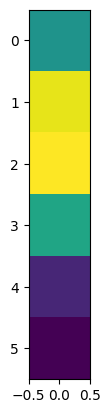

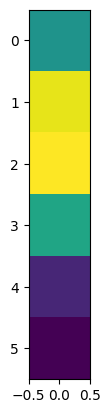

<Figure size 640x480 with 0 Axes>

In [17]:
window_length=12 
pred_length=6 #make len even to keep things simpler
batch_size = 1024#512 #too big?

#split into train and test datasets
split = 5700
train_data = data_all.iloc[:split, :]
test_data = data_all.iloc[split:, :] 

def preprocess(data, window_length = window_length, pred_length = pred_length):
    #flatten all stocks into one column  
    data = data.iloc[:, 1:].melt()
    data = data.iloc[:, 1]
    
    data = pd.to_numeric(data).to_numpy() #faster to do slicing operation as numpy array than pandas
    time_length = data.size

    #split into sections of length window_length, normalize, then put first half in x and second half in y
    x = [] 
    y = []
    for window_index in np.arange( np.random.randint(0,window_length-1), time_length-window_length-pred_length, window_length):  
        window = np.array(data[window_index:window_index+window_length])
        window = window-np.min(window) 
        window = window/np.max(window)

        x.append(window[0:pred_length])
        y.append(window[pred_length:window_length])
     
    x = np.asarray(x)
    y = np.asarray(y)

    #add positional enccoding
    x = np.reshape(x, [x.shape[0], x.shape[1], 1])#reshape into N, S, E where S is the source sequence length, T is the target sequence length, N is the batch size, EE is the feature number
    y = np.reshape(y, [y.shape[0], y.shape[1], 1]) 

    dim_model = 1 #number of features
    max_len = pred_length 

    position_encoding = np.zeros([max_len, dim_model], dtype=np.float32)
    position_list = np.reshape(np.arange(0, max_len, dtype=np.float32), [-1, 1])
    denominator = np.exp(-np.log(10000.0) * np.arange(0, dim_model, 2, dtype=np.float32)/dim_model) 
    position_encoding[:, 0::2] = np.sin(position_list / denominator)
    position_encoding[:, 1::2] = np.cos(position_list / denominator)

    plt.imshow(position_encoding)
    plt.figure()

    x[0, :, 0] = position_encoding[:, 0] #replace 2nd dim with positional encodings
    y[0, :, 0] = position_encoding[:, 0]
    
    return x, y


x_train, y_train = preprocess(train_data)
x_test, y_test = preprocess(test_data)

# print(x_train.shape)
# print(y_train.shape)
# print(x_train.dtype)

train_loader = DataLoader(list(zip(x_train, y_train)), batch_size, shuffle=True) #x is same as y for simple scalar transformers, right?
test_loader = DataLoader(list(zip(x_test, y_test)), batch_size, shuffle=True)

In [18]:
print(x_test.shape)
print(x_test[:, 0, :])

(126, 6, 1)
[[0.00000000e+00]
 [7.86096257e-01]
 [2.76536313e-01]
 [1.00000000e+00]
 [1.00000000e+00]
 [6.00276625e-01]
 [6.28062361e-01]
 [7.08520179e-02]
 [6.40432099e-02]
 [0.00000000e+00]
 [8.50961538e-01]
 [4.93877551e-02]
 [7.13858425e-01]
 [8.81284916e-01]
 [1.78907721e-01]
 [9.16812609e-01]
 [9.39376771e-01]
 [1.03631532e-01]
 [1.00000000e+00]
 [9.01116427e-02]
 [1.00000000e+00]
 [1.75621028e-01]
 [4.41094361e-02]
 [0.00000000e+00]
 [0.00000000e+00]
 [4.65576005e-01]
 [1.00000000e+00]
 [9.69920844e-01]
 [0.00000000e+00]
 [2.82142857e-01]
 [1.00000000e+00]
 [0.00000000e+00]
 [8.05687204e-02]
 [1.00000000e+00]
 [4.89010989e-01]
 [9.25480769e-01]
 [3.02259887e-01]
 [0.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.00000000e+00]
 [6.79462572e-01]
 [1.00000000e+00]
 [0.00000000e+00]
 [0.00000000e+00]
 [1.26903553e-01]
 [4.22413793e-01]
 [7.53424658e-02]
 [1.00000000e+00]
 [6.70940171e-01]
 [9.24170616e-02]
 [4.47368421e-01]
 [2.06157479e-02]
 [0.00000000e+00]
 [1.06508876e-01

In [19]:
# window_size = 16
# forecast_length = 16
# num_val = 2

# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime
# val_max_date = '2017-08-15'
# train_max_date = str((pd.to_datetime(val_max_date) - pd.Timedelta(days=window_size*num_val+forecast_length)).date())

# train_final = data_all[data_all['date']<=train_max_date]
# val_final = data_all[(data_all['date']>train_max_date)&(data_all['date']<=val_max_date)]

# train_series = train_final.groupby(categorical_static).agg(list).reset_index()
# val_series = val_final.groupby(categorical_static).agg(list).reset_index()

# #try changing date to ints
# train_series
# data_all['date'] = pd.to_datetime(data_all['date']) #convert int to datetime

In [20]:
# def divide_shuffle(df,div_num):
#     space = df.shape[0]//div_num
#     division = np.arange(0,df.shape[0],space)
#     return pd.concat([df.iloc[division[i]:division[i]+space,:].sample(frac=1) for i in range(len(division))])

# def create_time_blocks(time_length,window_size,forecast_length):
#     start_idx = np.random.randint(0,window_size-1)
#     end_idx = time_length-window_size-forecast_length-1
#     time_indices = np.arange(start_idx,end_idx+1,window_size)[:-1]
#     time_indices = np.append(time_indices,end_idx)
#     return time_indices

# def data_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, time_shuffle):

#     num_series = x_numeric_tensor.shape[0]
#     time_length = x_numeric_tensor.shape[1]
#     index_pd = pd.DataFrame({'serie_idx':range(num_series)})
#     index_pd['time_idx'] = [create_time_blocks(time_length,window_size,forecast_length) for n in range(index_pd.shape[0])]
#     if time_shuffle:
#         index_pd = index_pd.explode('time_idx')
#         index_pd = index_pd.sample(frac=1)
#     else:
#         index_pd = index_pd.explode('time_idx').sort_values('time_idx')
#         index_pd = divide_shuffle(index_pd,5)
#     indices = np.array(index_pd).astype(int)

#     for batch_idx in np.arange(0,indices.shape[0],batch_size):

#         cur_indices = indices[batch_idx:batch_idx+batch_size,:]

#         x_numeric = torch.stack([x_numeric_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_category = torch.stack([x_category_tensor[n[0],n[1]:n[1]+window_size,:] for n in cur_indices])
#         x_static = torch.stack([x_static_tensor[n[0],:] for n in cur_indices])
#         y = torch.stack([y_tensor[n[0],n[1]+window_size:n[1]+window_size+forecast_length] for n in cur_indices])

#         yield x_numeric.to(device), x_category.to(device), x_static.to(device), y.to(device)

# def val_loader(x_numeric_tensor, x_category_tensor, x_static_tensor, y_tensor, batch_size, num_val):

#     num_time_series = x_numeric_tensor.shape[0]

#     for i in range(num_val):

#       for batch_idx in np.arange(0,num_time_series,batch_size):

#           x_numeric = x_numeric_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_category = x_category_tensor[batch_idx:batch_idx+batch_size,window_size*i:window_size*(i+1),:]
#           x_static = x_static_tensor[batch_idx:batch_idx+batch_size]
#           y_val = y_tensor[batch_idx:batch_idx+batch_size,window_size*(i+1):window_size*(i+1)+forecast_length]

#           yield x_numeric.to(device), x_category.to(device), x_static.to(device), y_val.to(device)

In [21]:
# #medium model
# #don't need to run this block
# class transformer_block(nn.Module):

#     def __init__(self,embed_size,num_heads):
#         super(transformer_block, self).__init__()

#         self.attention = nn.MultiheadAttention(embed_size, num_heads, batch_first=True)
#         self.fc = nn.Sequential(nn.Linear(embed_size, 4 * embed_size),
#                                  nn.LeakyReLU(),
#                                  nn.Linear(4 * embed_size, embed_size))
#         self.dropout = nn.Dropout(drop_prob)
#         self.ln1 = nn.LayerNorm(embed_size, eps=1e-6)
#         self.ln2 = nn.LayerNorm(embed_size, eps=1e-6)

#     def forward(self, x):

#         attn_out, _ = self.attention(x, x, x, need_weights=False)
#         x = x + self.dropout(attn_out)
#         x = self.ln1(x)

#         fc_out = self.fc(x)
#         x = x + self.dropout(fc_out)
#         x = self.ln2(x)

#         return x


# class transformer_forecaster(nn.Module):

#     def __init__(self,embed_size,num_heads,num_blocks):
#         super(transformer_forecaster, self).__init__()

#         num_len = len(numeric_covariates)
#         self.embedding_cov = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_covariates_num_embeddings])
#         self.embedding_static = nn.ModuleList([nn.Embedding(n,embed_size-num_len) for n in categorical_static_num_embeddings])

#         self.blocks = nn.ModuleList([transformer_block(embed_size,num_heads) for n in range(num_blocks)])

#         self.forecast_head = nn.Sequential(nn.Linear(embed_size, embed_size*2),
#                                            nn.LeakyReLU(),
#                                            nn.Dropout(drop_prob),
#                                            nn.Linear(embed_size*2, embed_size*4),
#                                            nn.LeakyReLU(),
#                                            nn.Linear(embed_size*4, forecast_length),
#                                            nn.ReLU())

#     def forward(self, x_numeric, x_category, x_static):

#         tmp_list = []
#         for i,embed_layer in enumerate(self.embedding_static):
#             tmp_list.append(embed_layer(x_static[:,i]))
#         categroical_static_embeddings = torch.stack(tmp_list).mean(dim=0).unsqueeze(1)

#         tmp_list = []
#         for i,embed_layer in enumerate(self.embedding_cov):
#             tmp_list.append(embed_layer(x_category[:,:,i]))
#         categroical_covariates_embeddings = torch.stack(tmp_list).mean(dim=0)
#         T = categroical_covariates_embeddings.shape[1]

#         embed_out = (categroical_covariates_embeddings + categroical_static_embeddings.repeat(1,T,1))/2
#         x = torch.concat((x_numeric,embed_out),dim=-1)

#         for block in self.blocks:
#             x = block(x)

#         x = x.mean(dim=1)
#         x = self.forecast_head(x)

#         return x
    



# class RMSLELoss(nn.Module):

#     def __init__(self):
#         super().__init__()
#         self.mse = nn.MSELoss()

#     def forward(self, pred, actual):
#         return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1)))

In [22]:
class MyTransformerWrapper(nn.Module):
    def __init__(self, d_model=32, nhead=1, num_encoder_layers=6, num_decoder_layers=6):
        super().__init__()
        
        self.input_projection = nn.Linear(1, d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            batch_first=True
        )
        self.output_projection = nn.Linear(d_model, 1)

    def forward(self, src, tgt, src_mask=None, tgt_mask=None,
                src_is_causal=False, tgt_is_causal=False):
        
        src_emb = self.input_projection(src)  # shape: (B, S, 1) -> (B, S, d_model)
        tgt_emb = self.input_projection(tgt)  # shape: (B, T, 1) -> (B, T, d_model)

        transformer_out = self.transformer(
            src_emb, 
            tgt_emb,
            src_mask=src_mask, 
            tgt_mask=tgt_mask,
            src_is_causal=src_is_causal,
            tgt_is_causal=tgt_is_causal
        )  # shape: (B, T, d_model)

        out = self.output_projection(transformer_out)  # shape: (B, T, d_model) -> (B, T, 1)
        return out

In [23]:
#Pytorch vanilla transformer with MSE loss

# transformer_model = nn.Transformer(d_model = 1, nhead=1, num_encoder_layers=6, num_decoder_layers=6, batch_first=True, device=device) #only 1 head bc of 1 input dimension
# src = torch.rand((batch_size, window_length, 1)).to(device=device, dtype=dtype)#10, 32, 512)) #replace w ...
# tgt = torch.rand((batch_size, pred_length, 1)).to(device=device, dtype=dtype)#20, 32, 512))
# out = transformer_model(src, tgt).to(device=device, dtype=dtype) #MOVE TO CPU DEVICE????
# print(src.dtype)

class RMSLELoss(nn.Module):

    def __init__(self):
        super().__init__()
        self.mse = nn.MSELoss()

    def forward(self, pred, actual):
        return self.mse(pred, actual)
        #return torch.sqrt(self.mse(torch.log(pred + 1), torch.log(actual + 1))) #requires relu after final layer to avoid negative predictions from log loss

In [ ]:
#train the damn thing
train_losses = []
val_losses = []

num_epoch = 100#1000
min_val_loss = 1
data_folder = 'saved_models/'

learning_rate = 5e-4 #try smaller lr
time_shuffle = False
drop_prob = 0.1

model = MyTransformerWrapper(
    d_model=32, 
    nhead=1, 
    num_encoder_layers=6, 
    num_decoder_layers=6
).to(device)

criterion = RMSLELoss()
optimizer = torch.optim.Adam(model.parameters(),lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)
training_loss = []
validation_loss = []
for epoch in range(num_epoch):
    
    model.train()
    train_loss = 0
    counter = 0
    mask = nn.Transformer.generate_square_subsequent_mask(sz=pred_length, device=device) #generate casual mask #WAIT.... DIFFERENT MASK SIZES NOT GIVING ERROR
    
    for x_batch, y_batch in train_loader: 
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
       
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True).to(device=device)  #is the the correct place to enter the forward() parameters?
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred, y_batch).to(device=device)
        # print("loss:")
        # print(loss)
        optimizer.zero_grad()
        train_loss += loss.item()
        counter += 1
        loss.backward()

        # print("pred:")
        # print(pred)
        # print("y_batch:")
        # print(y_batch)
        # # Print gradients- ********************************8
        # for name, param in model.named_parameters():
        #     if param.grad is not None:
        #         print(f"{name} grad mean: {param.grad.mean().item():.6f}, "
        #               f"std: {param.grad.std().item():.6f}")
        #     else:
        #         print(f"{name} grad is None")

        optimizer.step()

    train_loss = train_loss/counter
    training_loss.append(train_loss)
    print(f'Epoch {epoch} training loss: {train_loss}')

    model.eval()
    val_loss = 0
    counter = 0
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device=device, dtype=dtype)
        y_batch = y_batch.to(device=device, dtype=dtype)
        with torch.no_grad():
            pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
            #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
            loss = criterion(pred,y_batch).item()
        val_loss += loss
        counter += 1
    val_loss = val_loss/counter
    validation_loss.append(val_loss)
    print(f'Epoch {epoch} validation loss: {val_loss}')

    if val_loss<min_val_loss:
      print('saved...')
      torch.save(model,data_folder+'best.model')
      min_val_loss = val_loss

    scheduler.step()

Epoch 0 training loss: 0.268144890666008
Epoch 0 validation loss: 0.10420317202806473
saved...
Epoch 1 training loss: 0.15226157195866108
Epoch 1 validation loss: 0.09202775359153748
saved...
Epoch 2 training loss: 0.12025427725166082
Epoch 2 validation loss: 0.0834563598036766
saved...
Epoch 3 training loss: 0.10770274233072996
Epoch 3 validation loss: 0.08223800361156464
saved...
Epoch 4 training loss: 0.10022283159196377
Epoch 4 validation loss: 0.0808723196387291
saved...
Epoch 5 training loss: 0.09599257074296474
Epoch 5 validation loss: 0.0784653052687645
saved...
Epoch 6 training loss: 0.0918300412595272
Epoch 6 validation loss: 0.0759776383638382
saved...
Epoch 7 training loss: 0.08823244459927082
Epoch 7 validation loss: 0.07274050265550613
saved...
Epoch 8 training loss: 0.08312219381332397
Epoch 8 validation loss: 0.0682990625500679
saved...
Epoch 9 training loss: 0.07762468326836824
Epoch 9 validation loss: 0.06135174259543419
saved...
Epoch 10 training loss: 0.070997104048

In [ ]:
# Plot the training loss function and validation accuracies
plt.subplot(2, 1, 1)
plt.plot(training_loss)
plt.title("Training Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(2, 1, 2)
# plt.plot(stats['train_acc_history'], label='train')
plt.plot(validation_loss, label="val")
plt.title("Validation Loss History")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [25]:
# #save the model
# print("Model's state_dic:")
# for param_tensor in model.state_dic():
#     print(param_tensor, "\t", model.state_dict()[param_tensor].size())

# torch.save(model.state_dict(), 'saved_models/toy_model.pt')

In [32]:
#test the model
data_folder = 'saved_models/'
model = torch.load(data_folder+'best.model', weights_only=False)
                   
truth_plot_data = torch.empty((0,pred_length,1))       #save data for visualization
pred_plot_data = torch.empty((0,pred_length,1))  #save data for visualization
truth_plot_data = truth_plot_data.to(device=device, dtype=dtype)
pred_plot_data = pred_plot_data.to(device=device, dtype=dtype)

model.eval()
val_loss = 0
counter = 0
for x_batch, y_batch in test_loader:
    x_batch = x_batch.to(device=device, dtype=dtype)
    y_batch = y_batch.to(device=device, dtype=dtype)
    truth_plot_data = torch.cat((truth_plot_data, y_batch))
    with torch.no_grad():
        pred = model(x_batch, y_batch, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)
        #pred = model(x_batch, y_batch)#, src_mask=mask, tgt_mask=mask, src_is_causal=True, tgt_is_causal=True)  #is the the correct place to enter the forward() parameters?
        loss = criterion(pred,y_batch).item()
        pred_plot_data = torch.cat((pred_plot_data, pred))
    val_loss += loss
    counter += 1
val_loss = val_loss/counter
print(f'Test loss: {val_loss}')

truth_plot_data = truth_plot_data.cpu()
pred_plot_data = pred_plot_data.cpu()

Test loss: 0.002352154580876231


In [27]:
pred_plot_data.shape
pred_plot_data

tensor([[[0.5229],
         [0.5004],
         [0.4674],
         [0.4526],
         [0.4763],
         [0.4829]],

        [[0.5402],
         [0.4996],
         [0.4541],
         [0.4761],
         [0.4885],
         [0.4988]],

        [[0.3495],
         [0.3474],
         [0.3651],
         [0.3679],
         [0.3911],
         [0.4128]],

        [[0.6409],
         [0.6556],
         [0.6657],
         [0.6721],
         [0.6790],
         [0.6746]],

        [[0.6882],
         [0.6819],
         [0.6781],
         [0.6757],
         [0.6748],
         [0.6735]],

        [[0.4700],
         [0.4573],
         [0.4308],
         [0.4205],
         [0.4066],
         [0.4007]],

        [[0.7291],
         [0.7290],
         [0.7284],
         [0.7294],
         [0.7293],
         [0.7293]],

        [[0.5898],
         [0.5885],
         [0.6021],
         [0.6116],
         [0.6257],
         [0.6358]],

        [[0.7033],
         [0.7012],
         [0.7082],
         [0.703

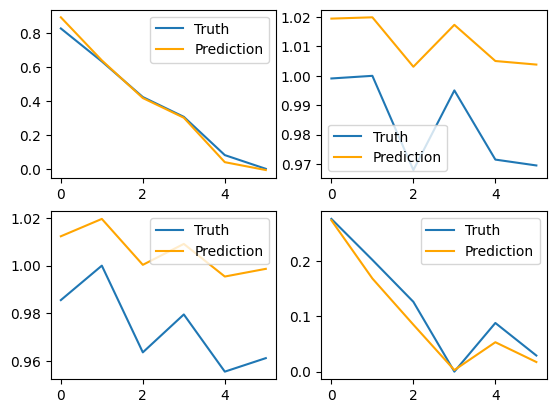

In [33]:
#truth_plot_data.shape
x_count = 2
y_count = 2
fig, axs = plt.subplots(x_count, y_count)

count = 0
for a in range(x_count):
    for b in range(y_count):
        axs[a, b].plot(truth_plot_data[count])
        axs[a, b].plot(pred_plot_data[count], 'orange')
        axs[a, b].legend(['Truth', 'Prediction'])
        count = count + 1

In [30]:
# Plot train and test curves
train_losses = []
test_losses = []
num_epochs = num_epoch
for epoch in range(num_epochs):
    # --- Train ---
    model.train()
    running_train_loss = 0
    for x_batch, y_batch in train_loader:
        # forward, backward, optimizer.step() ...
        running_train_loss += loss.item()
    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- Test / Validation ---
    model.eval()
    running_test_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            # forward only
            test_pred = model(x_batch, y_batch)
            test_loss_value = criterion(test_pred, y_batch).item()
            running_test_loss += test_loss_value
    avg_test_loss = running_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch}: train_loss={avg_train_loss}, test_loss={avg_test_loss}")

AttributeError: 'float' object has no attribute 'item'

In [ ]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Train/Test Loss Over Epochs')
plt.show()